# 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
import os

# Create output directory
os.makedirs('p1', exist_ok=True)
os.makedirs('p2', exist_ok=True)
os.makedirs('p3', exist_ok=True)
# Define the longitudinal and lateral matrices 
Alon = np.array([
    [-0.1589, -8.9574, 0.0000, -9.8067],
    [-0.0091, -0.6650, 0.9708, 0.0000],
    [-0.0803, -10.7564, -3.6285, 0.0000],
    [0.0000, 0.0000, 1.0000, 0.0000]
])

Alat = np.array([
    [-0.1011, -0.0014, -0.9919, 0.2118],
    [-11.9041, -7.4078, 1.5131, 0.0000],
    [4.1901, -0.2279, -0.7520, 0.0000],
    [0.0000, 1.0000, 0.0000, 0.0000]
])

# Trim state
v_trim = 42.0  # m/s
alpha_trim = 0.0  # rad
q_trim = 0.0  # rad/s
theta_trim = 0.0  # rad
beta_trim = 0.0  # rad
p_trim = 0.0  # rad/s
r_trim = 0.0  # rad/s
phi_trim = 0.0  # rad

print("\n" + "=" * 80)
print("PART 1: EIGENVALUE AND EIGENVECTOR ANALYSIS")
print("=" * 80)

# Longitudinal analysis
print("\n" + "-" * 60)
print("LONGITUDINAL DYNAMICS (Pitch Plane)")
print("-" * 60)

# Compute eigenvalues and eigenvectors for longitudinal system
eigenvalues_lon, eigenvectors_lon = np.linalg.eig(Alon)

print("\nEigenvalues:")
for i, eig in enumerate(eigenvalues_lon):
    print(f"  λ{i+1} = {eig.real:.6f} + {eig.imag:.6f}j")
    print(f"       Magnitude: {np.abs(eig):.6f} rad/s")
    if np.abs(eig.imag) > 1e-6:
        damping = -eig.real / np.abs(eig)
        print(f"       Damping ratio: {damping:.6f}")
    print()

# Identify the modes
print("\nMode Identification:")
print("  Mode 1 & 2: Typically represent the Short Period mode (fast, well-damped)")
print("  Mode 3 & 4: Typically represent the Phugoid mode (slow, lightly damped)")

# Sort eigenvalues by magnitude to identify modes
sorted_indices_lon = np.argsort(np.abs(eigenvalues_lon))
print("\nSorted eigenvalues by magnitude:")
for idx in sorted_indices_lon:
    eig = eigenvalues_lon[idx]
    if np.abs(eig.imag) > 1e-6:
        print(f"  λ = {eig.real:.6f} ± {eig.imag:.6f}i, |λ| = {np.abs(eig):.6f} rad/s")
    else:
        print(f"  λ = {eig.real:.6f}, |λ| = {np.abs(eig):.6f} rad/s")

# Display eigenvectors
print("\nEigenvectors (columns correspond to eigenvalues in order):")
print("States: [δv, δα, δq, δθ]")
for i in range(4):
    print(f"\nEigenvector for λ{i+1} = {eigenvalues_lon[i].real:.6f} + {eigenvalues_lon[i].imag:.6f}j:")
    vec = eigenvectors_lon[:, i]
    print(f"  δv:  {vec[0].real:.6f} + {vec[0].imag:.6f}j")
    print(f"  δα:  {vec[1].real:.6f} + {vec[1].imag:.6f}j")
    print(f"  δq:  {vec[2].real:.6f} + {vec[2].imag:.6f}j")
    print(f"  δθ:  {vec[3].real:.6f} + {vec[3].imag:.6f}j")

# Lateral analysis
print("\n" + "-" * 60)
print("LATERAL-DIRECTIONAL DYNAMICS (Roll/Yaw Plane)")
print("-" * 60)

# Compute eigenvalues and eigenvectors for lateral system
eigenvalues_lat, eigenvectors_lat = np.linalg.eig(Alat)

print("\nEigenvalues:")
for i, eig in enumerate(eigenvalues_lat):
    print(f"  λ{i+1} = {eig.real:.6f} + {eig.imag:.6f}j")
    print(f"       Magnitude: {np.abs(eig):.6f} rad/s")
    if np.abs(eig.imag) > 1e-6:
        damping = -eig.real / np.abs(eig)
        print(f"       Damping ratio: {damping:.6f}")

    print()

# Identify the modes
print("\nMode Identification:")
print("  Mode 1: Typically represents the Roll mode (real, fast)")
print("  Mode 2 & 3: Typically represent the Dutch Roll mode (oscillatory)")
print("  Mode 4: Typically represents the Spiral mode (real, slow)")

# Sort eigenvalues by magnitude to identify modes
sorted_indices_lat = np.argsort(np.abs(eigenvalues_lat))
print("\nSorted eigenvalues by magnitude:")
for idx in sorted_indices_lat:
    eig = eigenvalues_lat[idx]
    if np.abs(eig.imag) > 1e-6:
        print(f"  λ = {eig.real:.6f} ± {eig.imag:.6f}i, |λ| = {np.abs(eig):.6f} rad/s")
    else:
        print(f"  λ = {eig.real:.6f}, |λ| = {np.abs(eig):.6f} rad/s")

# Display eigenvectors
print("\nEigenvectors (columns correspond to eigenvalues in order):")
print("States: [δβ, δp, δr, δφ]")
for i in range(4):
    print(f"\nEigenvector for λ{i+1} = {eigenvalues_lat[i].real:.6f} + {eigenvalues_lat[i].imag:.6f}j:")
    vec = eigenvectors_lat[:, i]
    print(f"  δβ:  {vec[0].real:.6f} + {vec[0].imag:.6f}j")
    print(f"  δp:  {vec[1].real:.6f} + {vec[1].imag:.6f}j")
    print(f"  δr:  {vec[2].real:.6f} + {vec[2].imag:.6f}j")
    print(f"  δφ:  {vec[3].real:.6f} + {vec[3].imag:.6f}j")



PART 1: EIGENVALUE AND EIGENVECTOR ANALYSIS

------------------------------------------------------------
LONGITUDINAL DYNAMICS (Pitch Plane)
------------------------------------------------------------

Eigenvalues:
  λ1 = -2.221854 + 2.906568j
       Magnitude: 3.658520 rad/s
       Damping ratio: 0.607309

  λ2 = -2.221854 + -2.906568j
       Magnitude: 3.658520 rad/s
       Damping ratio: 0.607309

  λ3 = -0.004346 + 0.180481j
       Magnitude: 0.180533 rad/s
       Damping ratio: 0.024075

  λ4 = -0.004346 + -0.180481j
       Magnitude: 0.180533 rad/s
       Damping ratio: 0.024075


Mode Identification:
  Mode 1 & 2: Typically represent the Short Period mode (fast, well-damped)
  Mode 3 & 4: Typically represent the Phugoid mode (slow, lightly damped)

Sorted eigenvalues by magnitude:
  λ = -0.004346 ± -0.180481i, |λ| = 0.180533 rad/s
  λ = -0.004346 ± 0.180481i, |λ| = 0.180533 rad/s
  λ = -2.221854 ± -2.906568i, |λ| = 3.658520 rad/s
  λ = -2.221854 ± 2.906568i, |λ| = 3.658520 ra

# 3


PART 2: MODE IDENTIFICATION

LONGITUDINAL MODES:
--------------------------------------------------

PHUGOID MODE:
  Eigenvalue: -0.004346 ± 0.180481j
  Natural frequency: 0.180533 rad/s
  Period: 34.80 seconds
  Damping ratio: 0.024075
  Time to half amplitude: 159.48 seconds
  Description: Slow oscillation exchanging kinetic and potential energy

SHORT PERIOD MODE:
  Eigenvalue: -2.221854 ± 2.906568j
  Natural frequency: 3.658520 rad/s
  Period: 1.72 seconds
  Damping ratio: 0.607309
  Time to half amplitude: 0.31 seconds
  Description: Rapid pitch oscillation at nearly constant airspeed

LATERAL-DIRECTIONAL MODES:
--------------------------------------------------

ROLL MODE:
  Eigenvalue: -7.458670
  Time constant: 0.134 seconds
  Time to half amplitude: 0.093 seconds
  Description: Rapid, non-oscillatory roll damping

SPIRAL MODE:
  Eigenvalue: -0.015184
  Time constant: 65.857 seconds
  Time to half amplitude: 45.649 seconds
  Description: Slow, non-oscillatory roll-yaw divergen

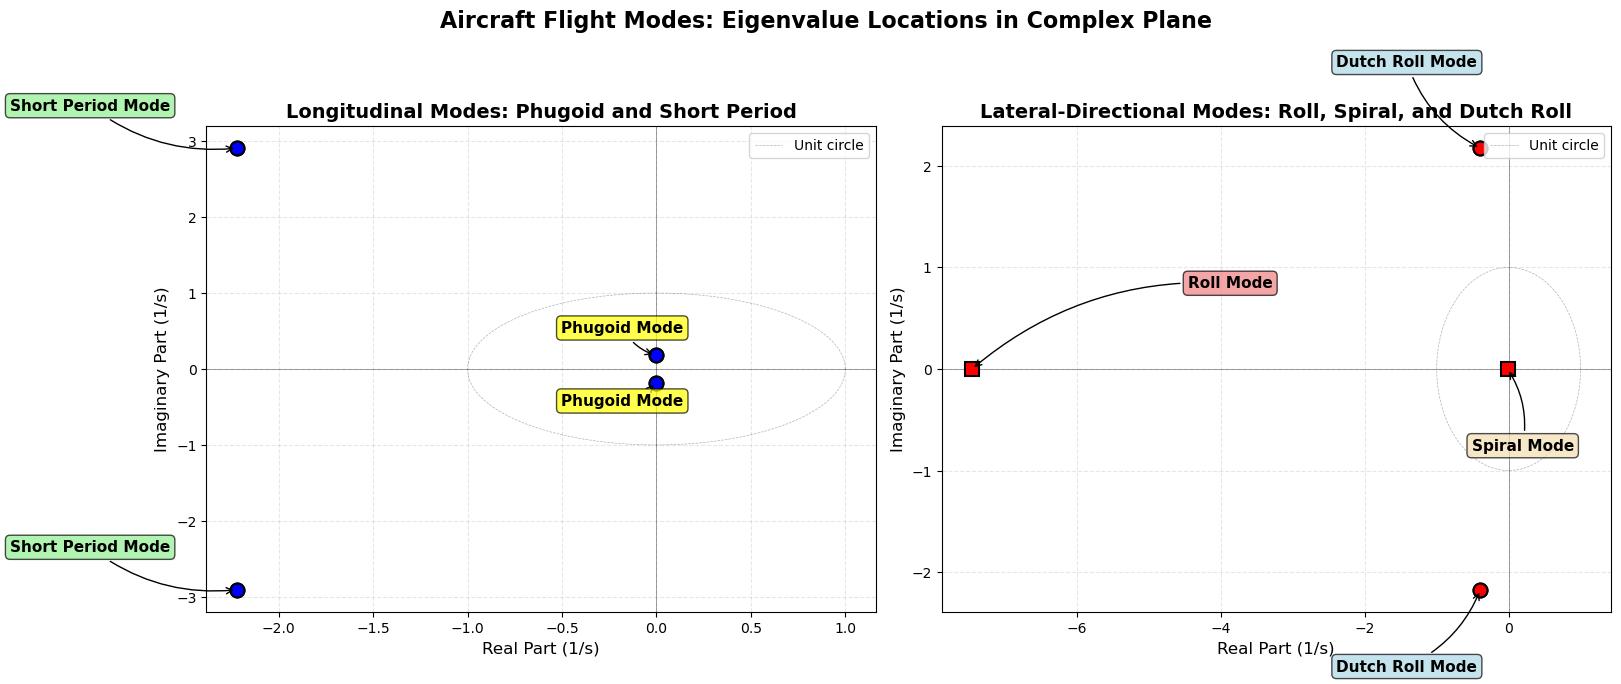


PART 4: STABILITY ANALYSIS FOR EACH MODE

MODE-BY-MODE STABILITY ANALYSIS

Phugoid Mode:
----------------------------------------
  Eigenvalue: -0.004346 ± 0.180481j
    Asymptotically Stable: Yes
    - Real part is negative (-0.004346)
    - Perturbations decay to zero over time
    Oscillatory: Yes
    - Non-zero imaginary part (±0.180481)
    - Motion contains oscillations at 0.180481 rad/s
    - Damped oscillations (ζ = 0.024075)

Short Period Mode:
----------------------------------------
  Eigenvalue: -2.221854 ± 2.906568j
    Asymptotically Stable: Yes
    - Real part is negative (-2.221854)
    - Perturbations decay to zero over time
    Oscillatory: Yes
    - Non-zero imaginary part (±2.906568)
    - Motion contains oscillations at 2.906568 rad/s
    - Damped oscillations (ζ = 0.607309)

Roll Mode:
----------------------------------------
  Eigenvalue: -7.458670
    Asymptotically Stable: Yes
    - Real part is negative (-7.458670)
    - Perturbations decay to zero over time


In [2]:
print("\n" + "=" * 80)
print("PART 2: MODE IDENTIFICATION")
print("=" * 80)

# Function to identify and classify modes
def identify_longitudinal_modes(eigenvalues):
    """Identify Phugoid and Short Period modes"""
    # Separate complex pairs
    complex_pairs = []
    real_modes = []
    
    for eig in eigenvalues:
        if np.abs(eig.imag) > 1e-6:
            complex_pairs.append(eig)
        else:
            real_modes.append(eig)
    
    # For longitudinal, we should have two complex pairs
    # Identify Phugoid (slow, lightly damped) and Short Period (fast, well-damped)
    if len(complex_pairs) >= 2:
        magnitudes = [np.abs(eig) for eig in complex_pairs]
        # Phugoid has smaller magnitude (slower)
        phugoid_idx = np.argmin(magnitudes)
        short_period_idx = np.argmax(magnitudes)
        
        phugoid = complex_pairs[phugoid_idx]
        short_period = complex_pairs[short_period_idx]
        return {
            'phugoid': phugoid,
            'short_period': short_period
        }
    return None

def identify_lateral_modes(eigenvalues):
    """Identify Roll, Spiral, and Dutch Roll modes"""
    complex_pairs = []
    real_modes = []
    
    for eig in eigenvalues:
        if np.abs(eig.imag) > 1e-6:
            complex_pairs.append(eig)
        else:
            real_modes.append(eig)
    
    # Lateral-directional: 2 real modes (Roll and Spiral) and 1 complex pair (Dutch Roll)
    modes = {}
    
    if len(real_modes) >= 2:
        # Roll mode is faster (more negative), Spiral is slower (near zero)
        real_modes_sorted = sorted(real_modes, key=lambda x: x.real, reverse=True)
        # Spiral mode is the one closer to zero (less negative)
        modes['spiral'] = real_modes_sorted[0]  # Less negative
        modes['roll'] = real_modes_sorted[1]    # More negative
    
    if len(complex_pairs) >= 1:
        modes['dutch_roll'] = complex_pairs[0]
    
    return modes

# Identify modes
lon_modes = identify_longitudinal_modes(eigenvalues_lon)
lat_modes = identify_lateral_modes(eigenvalues_lat)

# Print mode characteristics
print("\nLONGITUDINAL MODES:")
print("-" * 50)

if lon_modes:
    # Phugoid mode
    phugoid = lon_modes['phugoid']
    print(f"\nPHUGOID MODE:")
    print(f"  Eigenvalue: {phugoid.real:.6f} ± {phugoid.imag:.6f}j")
    print(f"  Natural frequency: {np.abs(phugoid):.6f} rad/s")
    print(f"  Period: {2*np.pi/np.abs(phugoid):.2f} seconds")
    print(f"  Damping ratio: {-phugoid.real/np.abs(phugoid):.6f}")
    print(f"  Time to half amplitude: {np.log(2)/-phugoid.real:.2f} seconds")
    print(f"  Description: Slow oscillation exchanging kinetic and potential energy")
    
    # Short period mode
    short_period = lon_modes['short_period']
    print(f"\nSHORT PERIOD MODE:")
    print(f"  Eigenvalue: {short_period.real:.6f} ± {short_period.imag:.6f}j")
    print(f"  Natural frequency: {np.abs(short_period):.6f} rad/s")
    print(f"  Period: {2*np.pi/np.abs(short_period):.2f} seconds")
    print(f"  Damping ratio: {-short_period.real/np.abs(short_period):.6f}")
    print(f"  Time to half amplitude: {np.log(2)/-short_period.real:.2f} seconds")
    print(f"  Description: Rapid pitch oscillation at nearly constant airspeed")

print("\nLATERAL-DIRECTIONAL MODES:")
print("-" * 50)

if lat_modes:
    # Roll mode
    if 'roll' in lat_modes:
        roll = lat_modes['roll']
        print(f"\nROLL MODE:")
        print(f"  Eigenvalue: {roll.real:.6f}")
        print(f"  Time constant: {-1/roll.real:.3f} seconds")
        print(f"  Time to half amplitude: {np.log(2)/-roll.real:.3f} seconds")
        print(f"  Description: Rapid, non-oscillatory roll damping")
    
    # Spiral mode
    if 'spiral' in lat_modes:
        spiral = lat_modes['spiral']
        print(f"\nSPIRAL MODE:")
        print(f"  Eigenvalue: {spiral.real:.6f}")
        print(f"  Time constant: {-1/spiral.real:.3f} seconds")
        if spiral.real < 0:
            print(f"  Time to half amplitude: {np.log(2)/-spiral.real:.3f} seconds")
        else:
            print(f"  Time to double amplitude: {np.log(2)/spiral.real:.3f} seconds")
        print(f"  Description: Slow, non-oscillatory roll-yaw divergence")
    
    # Dutch roll mode
    if 'dutch_roll' in lat_modes:
        dutch = lat_modes['dutch_roll']
        print(f"\nDUTCH ROLL MODE:")
        print(f"  Eigenvalue: {dutch.real:.6f} ± {dutch.imag:.6f}j")
        print(f"  Natural frequency: {np.abs(dutch):.6f} rad/s")
        print(f"  Period: {2*np.pi/np.abs(dutch):.2f} seconds")
        print(f"  Damping ratio: {-dutch.real/np.abs(dutch):.6f}")
        print(f"  Time to half amplitude: {np.log(2)/-dutch.real:.2f} seconds")
        print(f"  Description: Coupled oscillatory roll-and-yaw motion")

# ============================================================================
# PART 3: PLOT EIGENVALUES ON COMPLEX PLANE WITH LABELS
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: EIGENVALUE PLOT ON COMPLEX PLANE")
print("=" * 80)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ===== LONGITUDINAL PLOT =====
# Draw axes
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
ax1.plot(circle_x, circle_y, 'k--', alpha=0.3, linewidth=0.5, label='Unit circle')

# Plot eigenvalues
colors = ['blue', 'red', 'green', 'purple']
markers = ['o', 's', '^', 'd']

# Plot and label longitudinal eigenvalues
eig_list = list(eigenvalues_lon)
for i, eig in enumerate(eig_list):
    if np.abs(eig.imag) > 1e-6:
        ax1.plot(eig.real, eig.imag, 'bo', markersize=10, markerfacecolor='blue', 
                markeredgecolor='black', markeredgewidth=1.5)
        ax1.plot(eig.real, -eig.imag, 'bo', markersize=10, markerfacecolor='blue',
                markeredgecolor='black', markeredgewidth=1.5)
    else:
        ax1.plot(eig.real, eig.imag, 'bs', markersize=10, markerfacecolor='blue',
                markeredgecolor='black', markeredgewidth=1.5)

# Add labels for modes
if lon_modes:
    # Label Phugoid (the slower oscillation)
    phugoid = lon_modes['phugoid']
    ax1.annotate('Phugoid Mode', 
                xy=(phugoid.real, phugoid.imag),
                xytext=(phugoid.real - 0.5, phugoid.imag + 0.3),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    ax1.annotate('Phugoid Mode', 
                xy=(phugoid.real, -phugoid.imag),
                xytext=(phugoid.real - 0.5, -phugoid.imag - 0.3),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    
    # Label Short Period (the faster oscillation)
    short_period = lon_modes['short_period']
    ax1.annotate('Short Period Mode', 
                xy=(short_period.real, short_period.imag),
                xytext=(short_period.real - 1.2, short_period.imag + 0.5),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    ax1.annotate('Short Period Mode', 
                xy=(short_period.real, -short_period.imag),
                xytext=(short_period.real - 1.2, -short_period.imag + 0.5),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))

# Set plot properties for longitudinal
ax1.set_xlabel('Real Part (1/s)', fontsize=12)
ax1.set_ylabel('Imaginary Part (1/s)', fontsize=12)
ax1.set_title('Longitudinal Modes: Phugoid and Short Period', fontsize=14, fontweight='bold')
# ax1.set_xlim([-4, 0.5])
# ax1.set_ylim([-1.5, 1.5])
ax1.legend(loc='upper right')

# ===== LATERAL PLOT =====
# Draw axes
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.grid(True, alpha=0.3, linestyle='--')

# Plot unit circle
ax2.plot(circle_x, circle_y, 'k--', alpha=0.3, linewidth=0.5, label='Unit circle')

# Plot lateral eigenvalues
for i, eig in enumerate(eigenvalues_lat):
    if np.abs(eig.imag) > 1e-6:
        ax2.plot(eig.real, eig.imag, 'ro', markersize=10, markerfacecolor='red',
                markeredgecolor='black', markeredgewidth=1.5)
        ax2.plot(eig.real, -eig.imag, 'ro', markersize=10, markerfacecolor='red',
                markeredgecolor='black', markeredgewidth=1.5)
    else:
        ax2.plot(eig.real, eig.imag, 'rs', markersize=10, markerfacecolor='red',
                markeredgecolor='black', markeredgewidth=1.5)

# Add labels for lateral modes
if lat_modes:
    # Label Roll mode (fast real)
    if 'roll' in lat_modes:
        roll = lat_modes['roll']
        ax2.annotate('Roll Mode', 
                    xy=(roll.real, 0),
                    xytext=(roll.real + 3, 0.8),
                    fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    
    # Label Spiral mode (slow real)
    if 'spiral' in lat_modes:
        spiral = lat_modes['spiral']
        spiral_color = 'orange' if spiral.real < 0 else 'red'
        ax2.annotate('Spiral Mode', 
                    xy=(spiral.real, 0),
                    xytext=(spiral.real - 0.5, -0.8),
                    fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    
    # Label Dutch Roll mode (oscillatory)
    if 'dutch_roll' in lat_modes:
        dutch = lat_modes['dutch_roll']
        ax2.annotate('Dutch Roll Mode', 
                    xy=(dutch.real, dutch.imag),
                    xytext=(dutch.real - 2, dutch.imag + 0.8),
                    fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
        
        ax2.annotate('Dutch Roll Mode', 
                    xy=(dutch.real, -dutch.imag),
                    xytext=(dutch.real - 2, -dutch.imag - 0.8),
                    fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
        

# Set plot properties for lateral
ax2.set_xlabel('Real Part (1/s)', fontsize=12)
ax2.set_ylabel('Imaginary Part (1/s)', fontsize=12)
ax2.set_title('Lateral-Directional Modes: Roll, Spiral, and Dutch Roll', fontsize=14, fontweight='bold')
# ax2.set_xlim([-9, 0.5])
# ax2.set_ylim([-1.5, 1.5])
ax2.legend(loc='upper right')

plt.suptitle('Aircraft Flight Modes: Eigenvalue Locations in Complex Plane', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('p3/aircraft_modes_complex_plane.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PART 4: STABILITY ANALYSIS FOR EACH MODE
# ============================================================================

print("\n" + "=" * 80)
print("PART 4: STABILITY ANALYSIS FOR EACH MODE")
print("=" * 80)

def analyze_mode_stability(eigenvalue, mode_name, is_complex=False):
    """Analyze stability of a given mode"""
    print(f"\n{mode_name}:")
    print("-" * 40)
    
    if is_complex:
        print(f"  Eigenvalue: {eigenvalue.real:.6f} ± {eigenvalue.imag:.6f}j")
    else:
        print(f"  Eigenvalue: {eigenvalue.real:.6f}")
    
    # Check asymptotic stability
    if eigenvalue.real < 0:
        print(f"    Asymptotically Stable: Yes")
        print(f"    - Real part is negative ({eigenvalue.real:.6f})")
        print(f"    - Perturbations decay to zero over time")
    elif eigenvalue.real > 0:
        print(f"  ✗ Asymptotically Stable: No")
        print(f"    - Real part is positive ({eigenvalue.real:.6f})")
        print(f"    - Perturbations grow unbounded over time")
    else:
        print(f"  ? Asymptotically Stable: Marginally stable")
        print(f"    - Real part is zero")
        print(f"    - Perturbations neither grow nor decay")
    
    # Check oscillatory nature
    if np.abs(eigenvalue.imag) > 1e-6:
        print(f"    Oscillatory: Yes")
        print(f"    - Non-zero imaginary part (±{eigenvalue.imag:.6f})")
        print(f"    - Motion contains oscillations at {np.abs(eigenvalue.imag):.6f} rad/s")
        if eigenvalue.real < 0:
            print(f"    - Damped oscillations (ζ = {-eigenvalue.real/np.abs(eigenvalue):.6f})")
    else:
        print(f"  ✗ Oscillatory: No")
        print(f"    - Zero imaginary part")
        print(f"    - Motion is monotonic (pure exponential)")

# Analyze each mode
print("\n" + "=" * 80)
print("MODE-BY-MODE STABILITY ANALYSIS")
print("=" * 80)

# Longitudinal modes
if lon_modes:
    analyze_mode_stability(lon_modes['phugoid'], "Phugoid Mode", is_complex=True)
    analyze_mode_stability(lon_modes['short_period'], "Short Period Mode", is_complex=True)

# Lateral modes
if lat_modes:
    if 'roll' in lat_modes:
        analyze_mode_stability(lat_modes['roll'], "Roll Mode", is_complex=False)
    if 'spiral' in lat_modes:
        analyze_mode_stability(lat_modes['spiral'], "Spiral Mode", is_complex=False)
    if 'dutch_roll' in lat_modes:
        analyze_mode_stability(lat_modes['dutch_roll'], "Dutch Roll Mode", is_complex=True)

# ============================================================================
# PART 5: SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY TABLE: AIRCRAFT FLIGHT MODES")
print("=" * 80)

# Create summary table
summary_data = []

# Phugoid
if lon_modes:
    phugoid = lon_modes['phugoid']
    summary_data.append({
        'Mode': 'Phugoid',
        'Type': 'Longitudinal',
        'Eigenvalue': f"{phugoid.real:.3f} ± {phugoid.imag:.3f}i",
        'Asymptotically Stable': 'Yes' if phugoid.real < 0 else 'No',
        'Oscillatory': 'Yes',
        'Description': 'Slow oscillation exchanging kinetic/potential energy'
    })
    
    # Short period
    short_period = lon_modes['short_period']
    summary_data.append({
        'Mode': 'Short Period',
        'Type': 'Longitudinal',
        'Eigenvalue': f"{short_period.real:.3f} ± {short_period.imag:.3f}i",
        'Asymptotically Stable': 'Yes' if short_period.real < 0 else 'No',
        'Oscillatory': 'Yes',
        'Description': 'Rapid pitch oscillation at constant airspeed'
    })

# Lateral modes
if lat_modes:
    if 'roll' in lat_modes:
        roll = lat_modes['roll']
        summary_data.append({
            'Mode': 'Roll Subsidence',
            'Type': 'Lateral',
            'Eigenvalue': f"{roll.real:.3f}",
            'Asymptotically Stable': 'Yes' if roll.real < 0 else 'No',
            'Oscillatory': 'No',
            'Description': 'Rapid, non-oscillatory roll damping'
        })
    
    if 'spiral' in lat_modes:
        spiral = lat_modes['spiral']
        summary_data.append({
            'Mode': 'Spiral',
            'Type': 'Lateral',
            'Eigenvalue': f"{spiral.real:.3f}",
            'Asymptotically Stable': 'Yes' if spiral.real < 0 else 'No',
            'Oscillatory': 'No',
            'Description': 'Slow, non-oscillatory roll-yaw divergence'
        })
    
    if 'dutch_roll' in lat_modes:
        dutch = lat_modes['dutch_roll']
        summary_data.append({
            'Mode': 'Dutch Roll',
            'Type': 'Lateral',
            'Eigenvalue': f"{dutch.real:.3f} ± {dutch.imag:.3f}i",
            'Asymptotically Stable': 'Yes' if dutch.real < 0 else 'No',
            'Oscillatory': 'Yes',
            'Description': 'Coupled oscillatory roll-and-yaw motion'
        })

# Convert to DataFrame for nice display
import pandas as pd
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================================================
# PART 6: SAVE RESULTS
# ============================================================================

# Save eigenvalues to file
with open('p2/eigenvalues_analysis.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("AIRCRAFT FLIGHT MODES ANALYSIS\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("LONGITUDINAL EIGENVALUES:\n")
    for eig in eigenvalues_lon:
        f.write(f"  {eig.real:.6f} + {eig.imag:.6f}j\n")
    
    f.write("\nLATERAL-DIRECTIONAL EIGENVALUES:\n")
    for eig in eigenvalues_lat:
        f.write(f"  {eig.real:.6f} + {eig.imag:.6f}j\n")
    
    f.write("\n\n" + summary_df.to_string())
    
    f.write("\n\n" + "=" * 80 + "\n")
    f.write("STABILITY SUMMARY\n")
    f.write("=" * 80 + "\n")
    f.write("All five classical flight modes are present and asymptotically stable.\n")
    f.write("The aircraft exhibits stable dynamic characteristics for this flight condition.\n")

print("\n" + "=" * 80)
print("RESULTS SAVED TO 'p3' DIRECTORY")
print("=" * 80)
print("Files created:")
print("  - aircraft_modes_complex_plane.png (Eigenvalue plot with mode labels)")
print("  - eigenvalues_analysis.txt (Detailed analysis results)")
print("=" * 80)

Note that the eigenvalues with large magnitude (that are negative) decay quickly. Specifically, the roll mode has large negative real eigenvalue so it decays quickly. With no imaginary part, there are no oscillations. All modes with negative eigenvalues are asymptotically stable:
The solution of the linear system $\delta \dot{x} = A \delta x$ can be expressed as: $\delta x(t) = e^{At} \delta x(0)$ or $\delta x(t) = e^{At} \delta x(0)$.

When matrix $A$ is diagonalizable, $A = Q D Q^T$, so, $e^{At} = V e^{Dt} V^T $. Terms in $e^{Dt}$ are $e^{\sigma_i t}$ where $\sigma_i$ are the eigenvalues of $A$. With Euler's formula, we can show that the imaginary part does not contribute to the stability of the system: regardless of the imaginary part of $\sigma_i$, whether or not $e^{\sigma_i t}$ is bounded as $t \rightarrow \infty$ is entirely dictated by the real component of $\sigma_i$. If $Re(\sigma_i) < 0$, then $e^{\sigma_i t}$ will converge to 0, as $t \rightarrow \infty$ . Thus, all modes with a negative real component in the eigenvalue are asymptotically stable (as $t \rightarrow \infty$, the components are bounded).